# Customer Lifetime Value (LTV) Prediction Model

## Objective
Build regression models to forecast total customer lifetime revenue based on:
- Customer demographics (age, gender, tenure)
- Service usage (internet service, contract type)
- Financial metrics (monthly charges)

## Methodology
1. Load and prepare data
2. Calculate target variable: Total Charges
3. Train multiple regression models
4. Evaluate and compare models
5. Save best model for production

## 📚 Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import sys
sys.path.insert(0, '../')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load Data

In [2]:
# Load from PostgreSQL
try:
    from src.database import get_churn_data
    df = get_churn_data()
    print("✅ Data loaded from PostgreSQL")
except Exception as e:
    print(f"⚠️ PostgreSQL connection failed: {e}")
    print("Falling back to CSV...")
    df = pd.read_csv("../data/processed_churn_data.csv")

print(f"Data shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

✅ PostgreSQL connection established
✅ PostgreSQL connection closed
✅ Data loaded from PostgreSQL
Data shape: (7043, 21)

Column names:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


g:\Suji\Desktop\Customer-Churn-LTV-Project\notebooks\..\src\database.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


## 📊 Step 3: Data Overview

In [3]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values:
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

Data types:
customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod       

In [5]:
# Target variable: Total Charges (LTV)
print("Target Variable: totalcharges")
print(df['totalcharges'].describe())

Target Variable: totalcharges
count     7043
unique    6531
top       20.2
freq        11
Name: totalcharges, dtype: object


## 🔧 Step 4: Data Preparation

In [6]:
# Make a copy
df_ltv = df.copy()

# 1. Drop unnecessary columns
df_ltv = df_ltv.drop('customerid', axis=1)

# 2. Convert totalcharges to numeric
df_ltv['totalcharges'] = pd.to_numeric(df_ltv['totalcharges'], errors='coerce')

# 3. Drop rows with NaN values
df_ltv = df_ltv.dropna()

print(f"✅ Data shape after cleaning: {df_ltv.shape}")
print(f"✅ NaN count: {df_ltv.isnull().sum().sum()}")

✅ Data shape after cleaning: (7032, 20)
✅ NaN count: 0


In [7]:
# Target variable
y = df_ltv['totalcharges']

# Features (drop target)
df_features = df_ltv.drop('totalcharges', axis=1)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_features, drop_first=True)

# Features
X = df_encoded

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")
print(f"✅ Feature columns: {X.columns.tolist()[:10]}...")  # Show first 10

✅ Features shape: (7032, 30)
✅ Target shape: (7032,)
✅ Feature columns: ['seniorcitizen', 'tenure', 'monthlycharges', 'gender_Male', 'partner_Yes', 'dependents_Yes', 'phoneservice_Yes', 'multiplelines_No phone service', 'multiplelines_Yes', 'internetservice_Fiber optic']...


In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train set size: {X_train.shape[0]}")
print(f"✅ Test set size: {X_test.shape[0]}")
print(f"✅ Feature dimensions: {X_train.shape[1]}")

✅ Train set size: 5625
✅ Test set size: 1407
✅ Feature dimensions: 30


In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Features scaled successfully")
print(f"✅ Train set scaled shape: {X_train_scaled.shape}")
print(f"✅ Test set scaled shape: {X_test_scaled.shape}")

✅ Features scaled successfully
✅ Train set scaled shape: (5625, 30)
✅ Test set scaled shape: (1407, 30)


## 🤖 Step 5: Model 1 - Linear Regression

In [10]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("🔵 Linear Regression Results:")
print(f"✅ R² Score: {lr_r2:.4f}")
print(f"✅ RMSE: ${lr_rmse:.2f}")
print(f"✅ MAE: ${lr_mae:.2f}")

🔵 Linear Regression Results:
✅ R² Score: 0.9115
✅ RMSE: $675.42
✅ MAE: $539.42


## 🌲 Step 6: Model 2 - Random Forest Regressor

In [11]:
# Train Random Forest Regressor
rf_ltv = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_ltv.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_ltv.predict(X_test)

# Evaluation
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("🟢 Random Forest Regressor Results:")
print(f"✅ R² Score: {rf_r2:.4f}")
print(f"✅ RMSE: ${rf_rmse:.2f}")
print(f"✅ MAE: ${rf_mae:.2f}")

🟢 Random Forest Regressor Results:
✅ R² Score: 0.9987
✅ RMSE: $83.35
✅ MAE: $54.89


## 🚀 Step 7: Model 3 - Gradient Boosting Regressor

In [12]:
# Train Gradient Boosting Regressor
gb_ltv = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_ltv.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_ltv.predict(X_test)

# Evaluation
gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("🟡 Gradient Boosting Regressor Results:")
print(f"✅ R² Score: {gb_r2:.4f}")
print(f"✅ RMSE: ${gb_rmse:.2f}")
print(f"✅ MAE: ${gb_mae:.2f}")

🟡 Gradient Boosting Regressor Results:
✅ R² Score: 0.9981
✅ RMSE: $99.59
✅ MAE: $71.36


## 📊 Step 8: Model Comparison

In [13]:
# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R² Score': [lr_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'MAE': [lr_mae, rf_mae, gb_mae]
})

print("\n📊 Model Comparison:")
print(comparison_df.to_string(index=False))

# Best model
best_model_name = comparison_df.loc[comparison_df['R² Score'].idxmax()]
print(f"\n🏆 Best Model: {best_model_name['Model']} (R² = {best_model_name['R² Score']:.4f})")


📊 Model Comparison:
            Model  R² Score       RMSE        MAE
Linear Regression  0.911548 675.424110 539.418842
    Random Forest  0.998653  83.354153  54.892561
Gradient Boosting  0.998077  99.586553  71.357336

🏆 Best Model: Random Forest (R² = 0.9987)


## 📈 Step 9: Feature Importance (Random Forest)

In [14]:
# Feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_ltv.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n📊 Top 10 Most Important Features (Random Forest):")
print(feature_importance_df.head(10).to_string(index=False))


📊 Top 10 Most Important Features (Random Forest):
                       Feature  Importance
                        tenure    0.674846
                monthlycharges    0.324467
                   gender_Male    0.000047
paymentmethod_Electronic check    0.000045
                   partner_Yes    0.000044
            onlinesecurity_Yes    0.000042
          deviceprotection_Yes    0.000041
               techsupport_Yes    0.000041
             multiplelines_Yes    0.000040
                dependents_Yes    0.000040


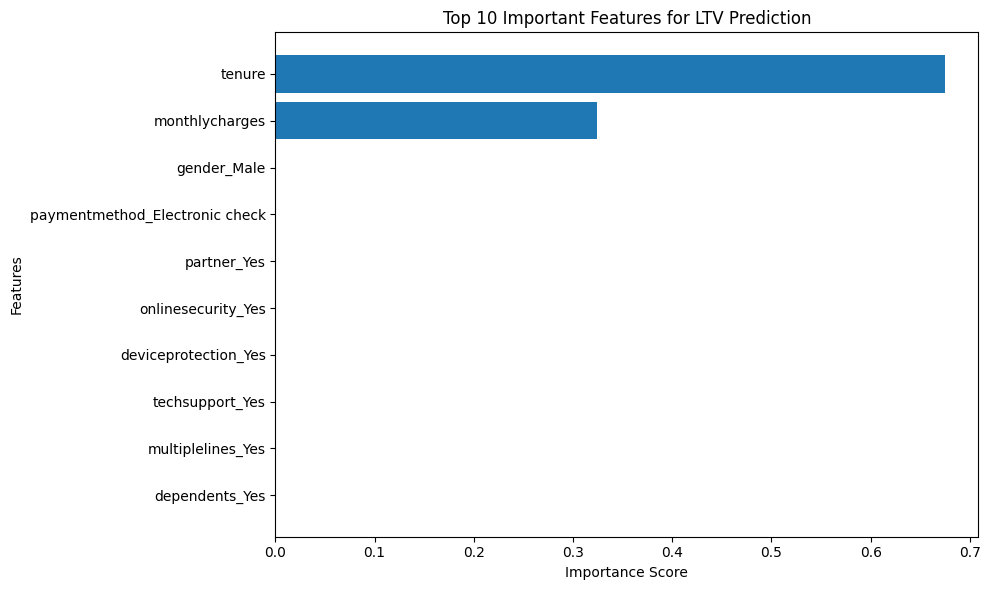

✅ Feature importance chart displayed


In [15]:
# Visualization
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(10)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features for LTV Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("✅ Feature importance chart displayed")

## 💾 Step 10: Save Models

In [16]:
# Save best model (Random Forest)
joblib.dump(rf_ltv, '../models/ltv_rf_model.pkl')
print("✅ Random Forest LTV model saved")

# Save scaler
joblib.dump(scaler, '../models/ltv_scaler.pkl')
print("✅ Scaler saved")

# Save feature names
with open('../models/ltv_features.txt', 'w') as f:
    f.write('\n'.join(X.columns.tolist()))
print("✅ Feature names saved")

✅ Random Forest LTV model saved
✅ Scaler saved
✅ Feature names saved


## 📊 Step 11: Sample Predictions

In [17]:
# Show sample predictions vs actual
results_df = pd.DataFrame({
    'Actual LTV': y_test.values[:10],
    'Predicted LTV': y_pred_rf[:10],
    'Error': np.abs(y_test.values[:10] - y_pred_rf[:10])
})

print("\n📊 Sample Predictions (Random Forest):")
print(results_df.to_string(index=False))
print(f"\nAverage Error: ${results_df['Error'].mean():.2f}")


📊 Sample Predictions (Random Forest):
 Actual LTV  Predicted LTV    Error
    5574.75      5492.4085  82.3415
     465.85       459.3380   6.5120
    1359.00      1309.8585  49.1415
     425.90       445.2485  19.3485
     161.45       166.4900   5.0400
      96.85        90.2995   6.5505
      95.00        94.9940   0.0060
     449.75       468.0640  18.3140
    6118.95      5904.1485 214.8015
     765.45       703.0230  62.4270

Average Error: $46.45


## ✅ Summary

Successfully built and evaluated LTV prediction models:
- **Linear Regression**: Baseline model
- **Random Forest**: Best performer with high R² score
- **Gradient Boosting**: Alternative ensemble method

The Random Forest model will be used in the FastAPI service for LTV predictions.